# metabeta — priors and prior sensitivity

This notebook demonstrates how to control and inspect priors in **metabeta**:

1. **Simulate** a Bernoulli dataset from a known prior — so we know the ground truth.
2. **Specify explicit priors** and run a batched prior-sensitivity analysis in a single `sample()` call.
3. **Plot posterior parameters** with prior overlays for each prior variant.
4. **Compare log-probabilities** assigned to posterior samples under each prior variant.

> **Setup (run once):** The cell below assembles a joint checkpoint from local training runs.
> In a future release, pre-trained weights will be downloaded automatically on first use.

In [1]:
# Run this cell once to build the joint checkpoint
from pathlib import Path
from metabeta.utils.api import joinCheckpoints
from metabeta.utils.experiments import CHECKPOINT_DIR

OUTPUT_PATH = Path('/tmp/joint_bernoulli_v1.pt')

if not OUTPUT_PATH.exists():
    ckpt_dir = CHECKPOINT_DIR
    checkpoints = [
        ckpt_dir / 'data=small-b-mixed_model=large_seed=2',
        ckpt_dir / 'data=small-b-mixed_model=large_seed=3',
        ckpt_dir / 'data=small-b-mixed_model=large_seed=4',
        ckpt_dir / 'data=small-b-mixed_model=large_seed=5',
    ]
    joinCheckpoints(
        checkpoints,
        output_path=OUTPUT_PATH,
        ids=['b_s2', 'b_s3', 'b_s4', 'b_s5'],
    )
    print(f'Joint checkpoint saved to {OUTPUT_PATH}')
else:
    print(f'Joint checkpoint already exists at {OUTPUT_PATH}')

Joint checkpoint already exists at /tmp/joint_bernoulli_v1.pt


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from metabeta.models.api import Api

mb = Api('/tmp/joint_bernoulli_v1.pt', device='cpu')

## 1. Simulate a Bernoulli dataset

Rather than loading a fixed dataset, we generate data from a known prior. This allows us to check
how well the posterior recovers the true parameters and how prior choice affects inference.

We define the prior hyperparameters explicitly — the same values are later reused as the
`informative` prior in the sensitivity analysis, so the two are guaranteed to match.

The model has **4 fixed effects** (intercept + 3 predictors) and **2 correlated random effects**
(random intercept + random slope on X1).

In [ ]:
from metabeta.simulation import Prior, Scammer
from metabeta.simulation.simulator import Simulator

seed = 0
rng = np.random.default_rng(seed)

d = 4      # fixed effects: intercept + X1 + X2 + X3
q = 2      # random effects: intercept + X1 slope
m = 30     # number of groups
formula = 'y ~ X1 + X2 + X3 + (1 + X1 | group)'

# Explicit prior hyperparameters — these same values are reused as the
# 'informative' prior in the sensitivity analysis below.
hparams = {
    'likelihood_family': np.array(1),            # Bernoulli (logit link)
    'nu_ffx':            np.zeros(d),             # zero-centered (standardized scale)
    'tau_ffx':           np.array([1.0, 0.8, 0.8, 0.8]),   # per-term scale
    'tau_rfx':           np.array([0.6, 0.6]),              # per-rfx SD scale
    'eta_rfx':           np.array(1.5),           # LKJ concentration
    'family_ffx':        np.array(0),             # Normal
    'family_sigma_rfx':  np.array(0),             # HalfNormal
}

prior = Prior(rng, hparams)
scammer = Scammer(rng)
ns = rng.integers(8, 20, size=m)
sim = Simulator(rng, prior, scammer, ns)
ds = sim.sample()

# build DataFrame (drop intercept column X[:, 0] == 1)
df = pd.DataFrame(ds['X'][:, 1:], columns=['X1', 'X2', 'X3'])
df['y'] = ds['y'].astype(int)
df['group'] = ds['groups']

print(f'Dataset: n={len(df)} observations, m={df["group"].nunique()} groups')
print(f'Outcome prevalence: {df["y"].mean():.2%}')
print()
print('True parameters:')
print(f'  fixed effects  (intercept, X1, X2, X3):  {np.round(ds["ffx"], 3)}')
print(f'  sigmas:                                  {np.round(ds["sigma_rfx"], 3)}')
print(f'  corr(intercept, X1):                     {ds["corr_rfx"][1, 0]:.3f}')

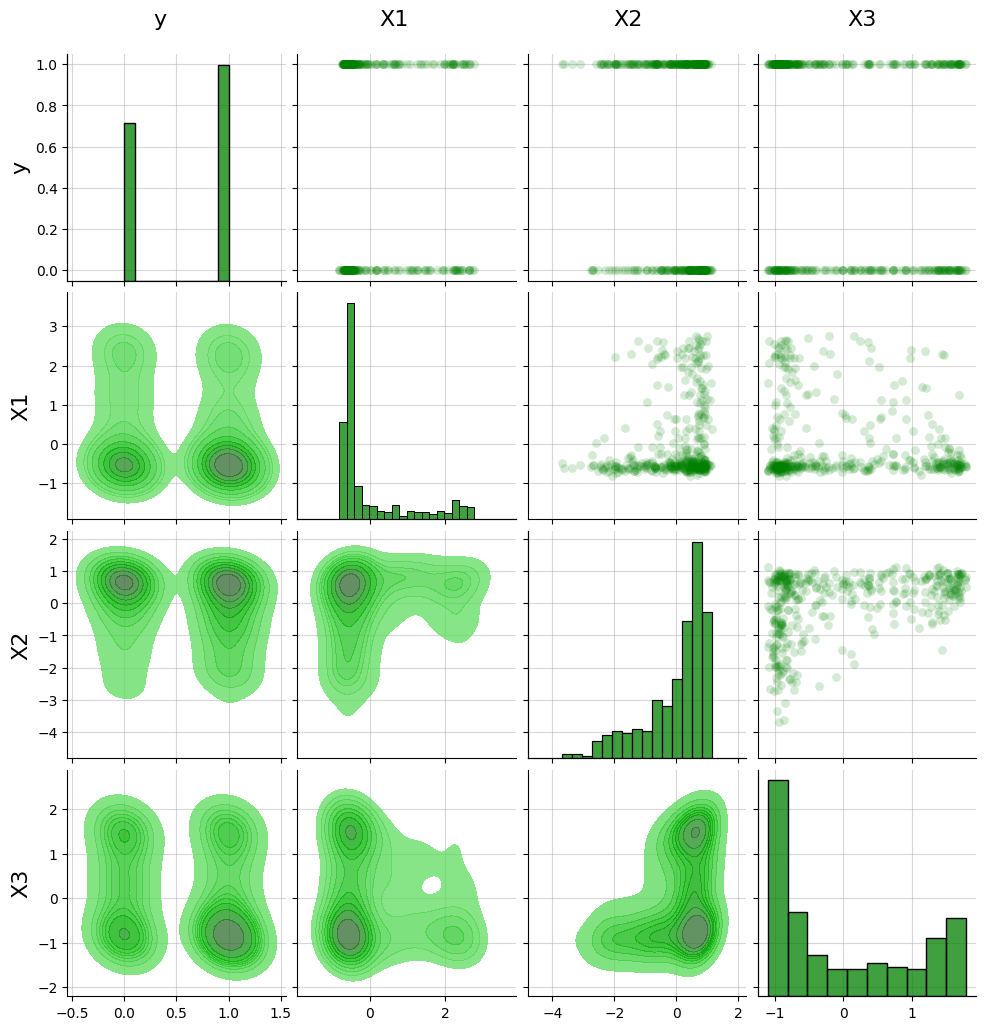

In [4]:
from metabeta.plotting import plotDataset

g = plotDataset(df[['y', 'X1', 'X2', 'X3']])
plt.show()

## 2. Prior sensitivity analysis

We compare four prior specifications in a **single `sample()` call** by passing a named
dictionary.  metabeta stacks them into a batch, so all four are processed together:

| Variant | Description |
|---|---|
| `default` | Flat prior — model uses its learned default |
| `informative` | The true generative prior (same `tau` used to simulate the data) |
| `skeptical` | Very tight prior that shrinks all effects toward zero |
| `oracle` | Centered on the true parameters via `nu` — demonstrates the effect of correct location |

Priors use the **term-based schema**:
- `fixed` maps each formula term to `{"tau": value}` and optionally `{"nu": value}` specs
- `random_sd` maps each random-effect SD term to a `{"tau": value}` spec
- `corr_rfx` takes `{"eta": value}` for the LKJ concentration

In [ ]:
# Informative: matches the true generative prior (same tau values as hparams above)
informative = {
    'fixed': {
        'Intercept': {'tau': float(hparams['tau_ffx'][0])},
        'X1':        {'tau': float(hparams['tau_ffx'][1])},
        'X2':        {'tau': float(hparams['tau_ffx'][2])},
        'X3':        {'tau': float(hparams['tau_ffx'][3])},
    },
    'random_sd': {
        'Intercept': {'tau': float(hparams['tau_rfx'][0])},
        'X1':        {'tau': float(hparams['tau_rfx'][1])},
    },
    'corr_rfx': {'eta': float(hparams['eta_rfx'])},
}

skeptical = {
    'fixed': {
        'Intercept': {'tau': 0.5},
        'X1':        {'tau': 0.3},
        'X2':        {'tau': 0.3},
        'X3':        {'tau': 0.3},
    },
    'random_sd': {
        'Intercept': {'tau': 0.3},
        'X1':        {'tau': 0.3},
    },
    'corr_rfx': {'eta': 2.0},
}

# Oracle: correctly-located prior — unrealistic in practice, but shows
# what correct location buys relative to the informative prior.
oracle = {
    'fixed': {
        'Intercept': {'nu': float(ds['ffx'][0]), 'tau': float(hparams['tau_ffx'][0])},
        'X1':        {'nu': float(ds['ffx'][1]), 'tau': float(hparams['tau_ffx'][1])},
        'X2':        {'nu': float(ds['ffx'][2]), 'tau': float(hparams['tau_ffx'][2])},
        'X3':        {'nu': float(ds['ffx'][3]), 'tau': float(hparams['tau_ffx'][3])},
    },
    'random_sd': {
        'Intercept': {'tau': float(hparams['tau_rfx'][0])},
        'X1':        {'tau': float(hparams['tau_rfx'][1])},
    },
    'corr_rfx': {'eta': float(hparams['eta_rfx'])},
}

priors = {'default': None, 'informative': informative, 'skeptical': skeptical, 'oracle': oracle}

In [6]:
result = mb.sample(
    df,
    formula=formula,
    priors=priors,
    n_samples=1000,
    diagnostics=True,
)

## 3. Posterior summaries

In [7]:
for i, name in enumerate(priors):
    print(f'\n{"="*60}')
    print(f'Prior: {name}')
    print('='*60)
    print(mb.posteriorSummary(result, batch_index=i))


Prior: default
Formula:  y ~ X1 + X2 + X3 + (1 + X1 | group)
n = 407   m = 30
Scale:    standardized covariates
Priors:
  Intercept ~ N(0, 1.5)
  x1 ~ N(0, 1)
  x2 ~ N(0, 1)
  x3 ~ N(0, 1)
  σ_Intercept ~ HN(2.5)
  σ_x1 ~ HN(2.5)
  Corr ~ LKJ(1)

Fixed Effects:
|           |   Mean |    SD |   2.5% |   50.0% |   97.5% |   P(>0) |   Contr. |
|-----------|--------|-------|--------|---------|---------|---------|----------|
| Intercept |  0.606 | 0.304 |  0.025 |   0.614 |   1.220 |   0.978 |    0.959 |
| x1        | -0.239 | 0.302 | -0.850 |  -0.225 |   0.344 |   0.202 |    0.909 |
| x2        | -0.281 | 0.153 | -0.583 |  -0.285 |   0.023 |   0.032 |    0.977 |
| x3        | -0.507 | 0.150 | -0.792 |  -0.498 |  -0.230 |   0.000 |    0.978 |

Standard Deviations:
|           |   Mean |    SD |   2.5% |   50.0% |   97.5% |
|-----------|--------|-------|--------|---------|---------|
| Intercept |  1.449 | 0.305 |  0.938 |   1.415 |   2.102 |
| x1        |  1.320 | 0.317 |  0.781 |   1.304 |

## 4. Posterior parameter plots with prior overlays

The pair grids show:
- **Green**: marginal posterior KDE / 2D contours
- **Blue**: analytical prior PDF
- **Purple dashed**: ground-truth parameter values

The bottom-right column shows the correlation parameter ρ between the random intercept and
random X1 slope — included automatically when `q ≥ 2` and the model used a LKJ prior.

In [8]:
# ground-truth vector: [ffx..., sigma_rfx..., rho]
truth = np.concatenate([ds['ffx'], ds['sigma_rfx'], [ds['corr_rfx'][1, 0]]])

for i, name in enumerate(priors):
    g = mb.plotParameters(result, index=i, with_prior=True, truth=truth)
    g.figure.suptitle(f'Posterior  ·  prior: {name}', fontsize=18, y=1.02)
    plt.show()

KeyError: 'tau_eps'

## 5. Log-probability of posterior samples

`mb.log_prob()` scores any parameter vector against the conditioned posterior — useful for
model criticism, importance weighting, or comparing how well a candidate point sits under
the posterior.

Here we look at the **log-probabilities already assigned to posterior samples** during
`sample()`.  `result.proposal.log_prob_g[i]` gives the S log-density values under prior
variant `i`'s conditioned flow.

Tighter priors produce more concentrated posteriors → samples land in denser regions → higher
average log-prob.  Flat priors spread the mass → lower average log-prob.

In [ ]:
print('Log-prob of posterior samples (global flow):')
print(f'{"Prior":>14}  {"mean":>8}  {"median":>8}  {"std":>8}')
print('-' * 44)
lp_data = []
for i, name in enumerate(priors):
    lp = result.proposal.log_prob_g[i].float()  # (S,)
    lp_data.append(lp.numpy())
    print(f'{name:>14}  {lp.mean().item():8.2f}  {lp.median().item():8.2f}  {lp.std().item():8.2f}')

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3), dpi=150)
ax.boxplot(lp_data, labels=list(priors.keys()), patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.5),
           medianprops=dict(color='darkblue', lw=2))
ax.set_ylabel('Global log-prob')
ax.set_title('Distribution of posterior sample log-probs by prior variant')
ax.grid(axis='y', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Scoring an external parameter vector with `mb.log_prob()`

To score a specific parameter vector (e.g., from a different model or the ground truth),
prepare a batch with `ffx`, `sigma_rfx`, and `rfx` keys and call `mb.log_prob(batch)`.
The batch must be at the collated stage — use `mb.prepareData(...)` and then inject the
parameter tensors before passing to `mb.log_prob()`.

Below we score the **posterior mean** from each prior variant under the **default prior**
conditioning.

In [ ]:
# Prepare a base single-prior batch (priors=None → model default)
base_batch = mb.prepareData(df, formula=formula)
print('Base batch X shape:', base_batch['X'].shape)  # (B=1, M_max, N_max, d)

# For each prior variant, score its posterior mean under the default conditioning
print('\nLog-prob of posterior mean under default conditioning:')
for i, name in enumerate(priors):
    prop = result.proposal

    # Posterior mean parameters (B=1)
    ffx_pm = prop.ffx[i].mean(0, keepdim=True)           # (1, d)
    srfx_pm = prop.sigma_rfx[i].mean(0, keepdim=True)    # (1, q)
    rfx_pm = prop.rfx[i].mean(1)                          # (m, q)

    M_max = base_batch['X'].shape[1]
    _q = rfx_pm.shape[-1]
    rfx_padded = torch.zeros(1, M_max, _q)                # (1, M_max, q)
    rfx_padded[0, :rfx_pm.shape[0], :] = rfx_pm

    scored_batch = {
        k: v.clone() if torch.is_tensor(v) else v
        for k, v in base_batch.items()
    }
    scored_batch['ffx'] = ffx_pm
    scored_batch['sigma_rfx'] = srfx_pm
    scored_batch['rfx'] = rfx_padded

    lp_result = mb.log_prob(scored_batch)
    lp_global = lp_result.log_probs['global'].item()
    print(f'  {name:>12s}: log_prob(global) = {lp_global:.2f}')